In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

gen_results = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_mean_std.npz')
gen_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real_ln/depth_4_epochs_10000_schedule_VE_sigma_5/generated_samples.npz')
real_samples = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real_ln/depth_4_epochs_10000_schedule_VE_sigma_5/real_samples.npz')
conditional_inputs = np.load('/Users/isaaclee/Wildfire_Research/wildfire_results_real_ln/depth_4_epochs_10000_schedule_VE_sigma_5/conditional_inputs.npz')
# training_testing_data = np.load('/Users/isaaclee/Wildfire_Research/data/training_testing_data_for_predicting_fire_area_from_ign_time_conditions.npy')
# testing_data = training_testing_data[-1200:]

print(gen_results.files)
print(gen_samples.files)
print(real_samples.files)
print(conditional_inputs.files)

['array1', 'array2']
['arr_0']
['arr_0']
['arr_0']


In [2]:
scales = np.load('/Users/isaaclee/Wildfire_Research/data/real_x_scaling_factor.npz')
x_max = scales['x_max']

# unnormalize generated samples
gen_samples_raw = gen_samples['arr_0']
gen_samples_unnorm = np.exp(gen_samples_raw * x_max)

# unnormalize generated means
gen_means_raw = gen_results['array1']
gen_means_unnorm = np.exp(gen_means_raw * x_max)

# unnormalize real samples
real_samples_raw = real_samples['arr_0']
real_samples_unnorm = np.exp(real_samples_raw * x_max)

# standard deviation
gen = gen_samples_unnorm.reshape(8,1000)
stds = np.std(gen, axis=1)

print(gen_means_unnorm)

[[3591.2250685 ]
 [1670.78601754]
 [6866.18668187]
 [2526.33442766]
 [3357.45146686]
 [1641.31124948]
 [6715.11868306]
 [2496.46954815]]


In [3]:
real = real_samples_unnorm
pred = gen_means_unnorm
print(real.shape)
print(pred.shape)

mae = np.mean(np.abs(real-pred))
print("Mean Absolute Error: " + str(mae))

normalized_mae = mae/np.mean(real)
print("Normalized Mean Absolute Error: " + str(normalized_mae))

mape = np.mean(np.abs(real-pred)/real)
print("Mean Absolute Percent Error: " + str(mape))


(8, 1)
(8, 1)
Mean Absolute Error: 7861.3631731695095
Normalized Mean Absolute Error: 0.701678260821587
Mean Absolute Percent Error: 0.593253931615911


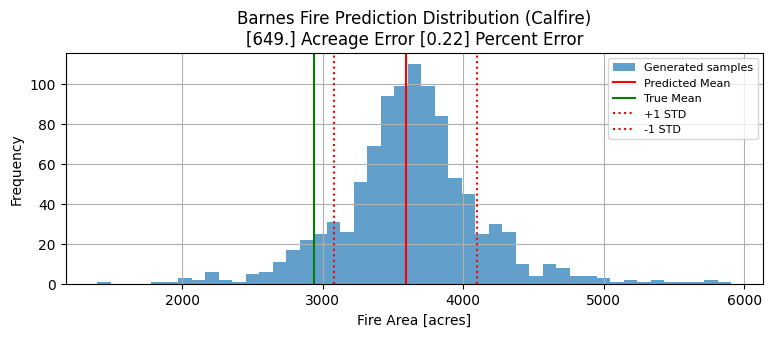

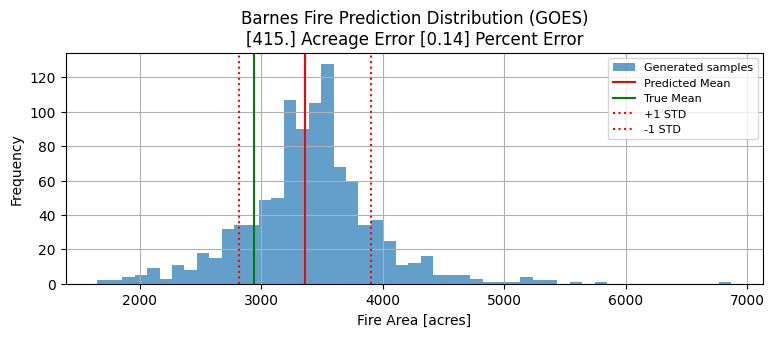

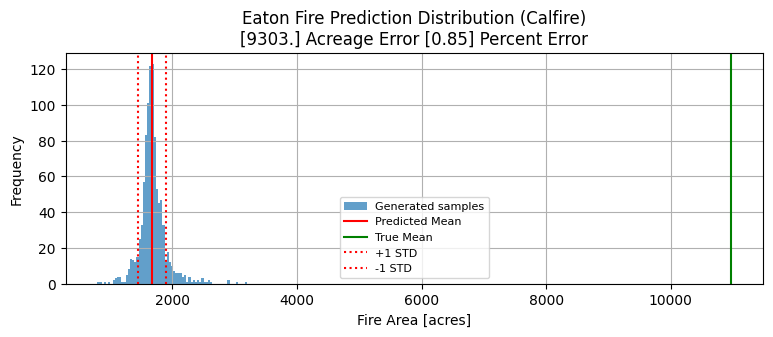

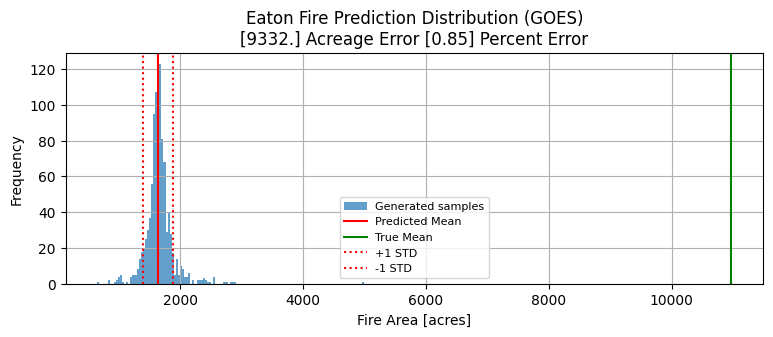

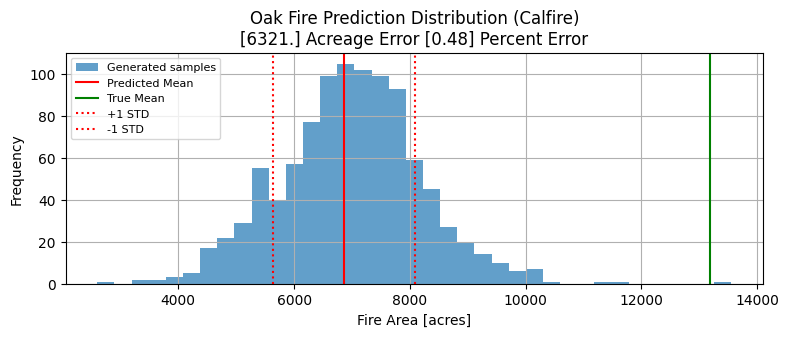

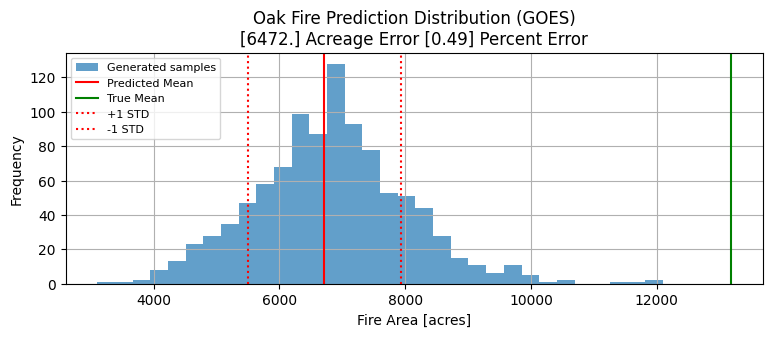

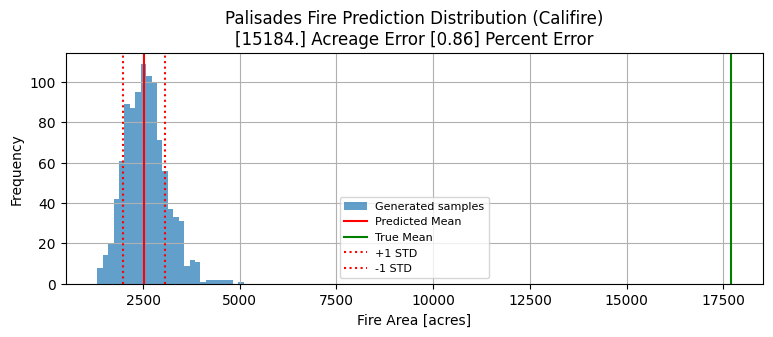

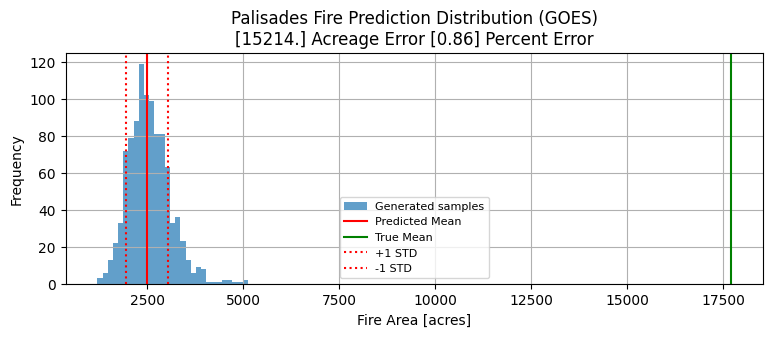

In [4]:
means = pred
gen_all = gen

percent_error = np.round(np.abs((means[0]-real[0])/real[0]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Barnes Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[0]-means[0]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[0], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[0], color='red', label='Predicted Mean')
plt.axvline(real[0], color='green', label='True Mean')
plt.axvline(means[0]+stds[0], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[0]-stds[0], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[4]-real[4])/real[4]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Barnes Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[4]-means[4]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[4], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[4], color='red', label='Predicted Mean')
plt.axvline(real[4], color='green', label='True Mean')
plt.axvline(means[4]+stds[4], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[4]-stds[4], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[1]-real[1])/real[1]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Eaton Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[1]-means[1]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[1], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[1], color='red', label='Predicted Mean')
plt.axvline(real[1], color='green', label='True Mean')
plt.axvline(means[1]+stds[1], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[1]-stds[1], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[5]-real[5])/real[5]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Eaton Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[5]-means[5]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[5], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[5], color='red', label='Predicted Mean')
plt.axvline(real[5], color='green', label='True Mean')
plt.axvline(means[5]+stds[5], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[5]-stds[5], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[2]-real[2])/real[2]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Oak Fire Prediction Distribution (Calfire)\n' + str(np.round(np.abs(real[2]-means[2]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[2], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[2], color='red', label='Predicted Mean')
plt.axvline(real[2], color='green', label='True Mean')
plt.axvline(means[2]+stds[2], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[2]-stds[2], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[6]-real[6])/real[6]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Oak Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[6]-means[6]))) + ' Acreage Error ' + str(percent_error) + ' Percent Error')
plt.hist(gen_all[6], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[6], color='red', label='Predicted Mean')
plt.axvline(real[6], color='green', label='True Mean')
plt.axvline(means[6]+stds[6], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[6]-stds[6], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[3]-real[3])/real[3]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Palisades Fire Prediction Distribution (Califire)\n' + str(np.round(np.abs(real[3]-means[3]))) + ' Acreage Error '  + str(percent_error) + ' Percent Error')
plt.hist(gen_all[3], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[3], color='red', label='Predicted Mean')
plt.axvline(real[3], color='green', label='True Mean')
plt.axvline(means[3]+stds[3], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[3]-stds[3], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()

percent_error = np.round(np.abs((means[7]-real[7])/real[7]),decimals=2)
plt.figure(figsize=(9,3))
plt.title('Palisades Fire Prediction Distribution (GOES)\n' + str(np.round(np.abs(real[7]-means[7]))) + ' Acreage Error '  + str(percent_error) + ' Percent Error')
plt.hist(gen_all[7], bins='auto', alpha=0.7, label='Generated samples') 
plt.xlabel('Fire Area [acres]')
plt.ylabel('Frequency')
plt.grid(True)
plt.axvline(means[7], color='red', label='Predicted Mean')
plt.axvline(real[7], color='green', label='True Mean')
plt.axvline(means[7]+stds[7], color='red', label='+1 STD', linestyle=':')
plt.axvline(means[7]-stds[7], color='red', label='-1 STD', linestyle=':')
plt.legend(fontsize='8')
plt.show()